<a href="https://colab.research.google.com/github/ROKEYAKHATUN/CIFAR-10_Image_Classification_using_CNN/blob/main/CIFAR_10_Image_Classification_using_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import tensorflow as tf
import tensorflow.keras as keras

In [6]:
from tensorflow.keras.datasets import cifar10
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

In [3]:
print("Training Images Shape:", x_train.shape)
print("Training Labels Shape:", y_train.shape)

Training Images Shape: (50000, 32, 32, 3)
Training Labels Shape: (50000, 1)


In [4]:
print("Testing Images Shape:", x_test.shape)
print("Testing Labels Shape:", y_test.shape)

Testing Images Shape: (10000, 32, 32, 3)
Testing Labels Shape: (10000, 1)


In [7]:
class_names = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]

print(class_names)

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


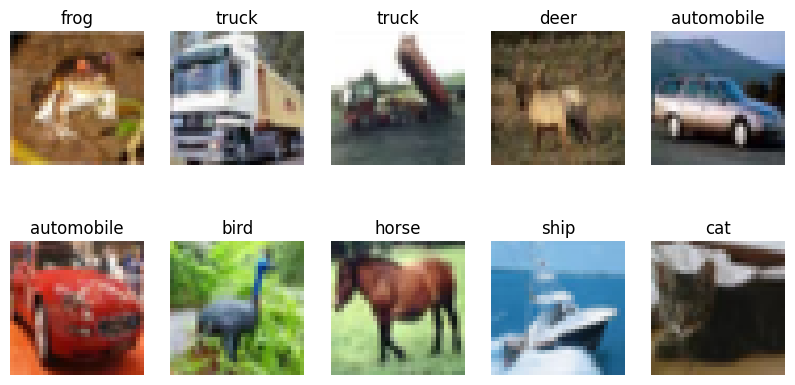

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')

plt.show()

In [10]:
print("Minimum Pixel Value:", x_train.min())
print("Maximum Pixel Value:", x_train.max())

Minimum Pixel Value: 0
Maximum Pixel Value: 255


In [11]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [18]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

In [19]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([


    Conv2D(32,(3,3),activation='relu',
           input_shape=(32,32,3)),
    MaxPooling2D(2,2),

    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128,(3,3),activation='relu'),

    Flatten(),

    Dense(128,activation='relu'),

    Dropout(0.5),

    Dense(10,activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [20]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [29]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,070,432 (4.08 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 713,622 (2.72 MB)

In [21]:
history = model.fit(
    datagen.flow(x_train,y_train,batch_size=64),
    epochs=20,
    validation_data=(x_test,y_test)
)

Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 94s 117ms/step - accuracy: 0.3434 - loss: 1.7739 - val_accuracy: 0.4522 - val_loss: 1.5070
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 90s 115ms/step - accuracy: 0.4768 - loss: 1.4460 - val_accuracy: 0.5574 - val_loss: 1.2628
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 90s 115ms/step - accuracy: 0.5318 - loss: 1.3171 - val_accuracy: 0.6049 - val_loss: 1.1024
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 90s 115ms/step - accuracy: 0.5659 - loss: 1.2261 - val_accuracy: 0.6097 - val_loss: 1.0881
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 90s 115ms/step - accuracy: 0.5926 - loss: 1.1613 - val_accuracy: 0.6757 - val_loss: 0.9348
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 142s 115ms/step - accuracy: 0.6147 - loss: 1.1047 - val_accuracy: 0.6558 - val_loss: 0.9953
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 90s 115ms/step - accuracy: 0.6335 - loss: 1.0513 - val_accuracy: 0.6900 - val_loss: 0.8999
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 89s 114ms/step - accuracy: 0.6510 - loss: 

In [31]:
loss, accuracy = model.evaluate(x_test,y_test)

print("Accuracy:",accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.7581 - loss: 0.7037
Accuracy: 0.7580999732017517


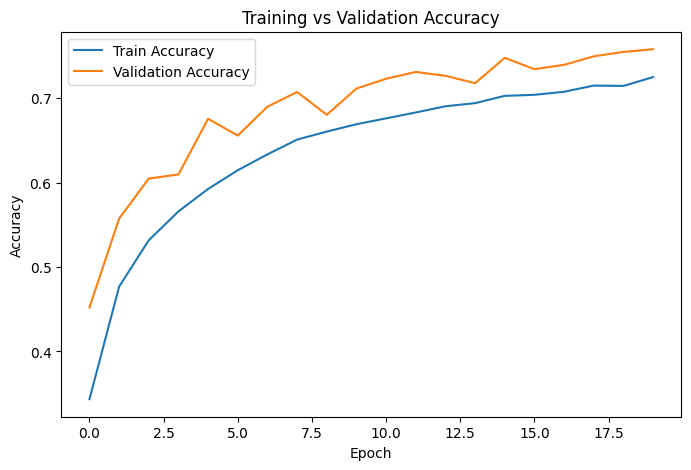

In [33]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'],label='Train Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

plt.show()

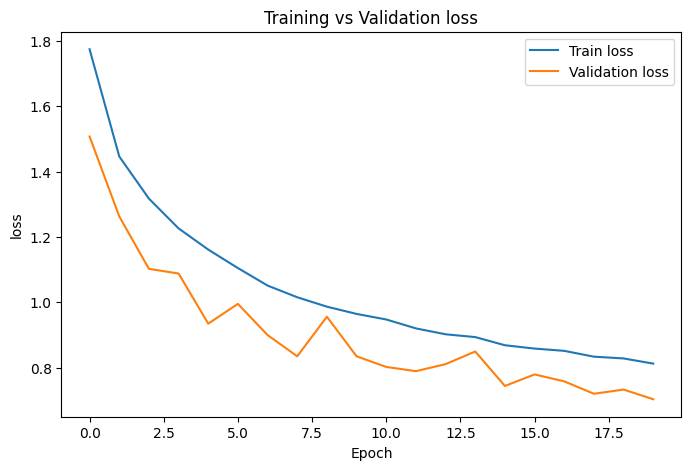

In [34]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'],label='Train loss')
plt.plot(history.history['val_loss'],label='Validation loss')

plt.xlabel('Epoch')
plt.ylabel('loss')
plt.title('Training vs Validation loss')
plt.legend()

plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step


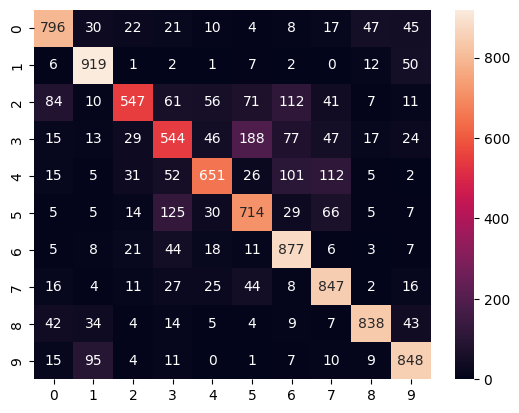

In [38]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(
    y_test,
    y_pred_classes
)

sns.heatmap(cm,annot=True,fmt='d')
plt.show()

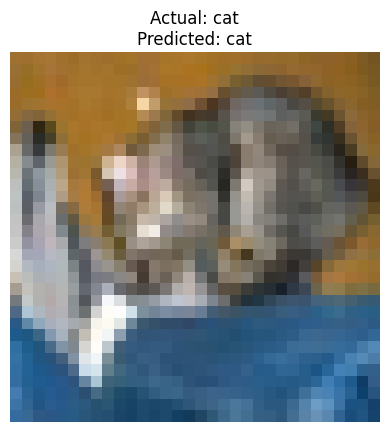

In [37]:
plt.imshow(x_test[0])
plt.title(
    f"Actual: {class_names[y_test[0][0]]}\n"
    f"Predicted: {class_names[predicted_class]}"
)
plt.axis('off')
plt.show()